In [6]:

# CELL 1: IMPORT THƯ VIỆN
import os, shutil, random, warnings, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                         ModelCheckpoint)
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
warnings.filterwarnings('ignore')

tf.config.threading.set_intra_op_parallelism_threads(0)
tf.config.threading.set_inter_op_parallelism_threads(0)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

print("✅ TensorFlow:", tf.__version__)
print("✅ Thiết bị  :", tf.config.list_physical_devices())
print("✅ Số nhân CPU:", os.cpu_count())

✅ TensorFlow: 2.20.0
✅ Thiết bị  : [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
✅ Số nhân CPU: 16


In [7]:

# CELL 2: CẤU HÌNH

# ── Đường dẫn RAF-DB ─────────────────────────────────────────────────
RAFDB_DIR       = r"D:\XuLyAnh\RAF-DB"
RAFDB_TRAIN_DIR = os.path.join(RAFDB_DIR, "DATASET", "train")
RAFDB_TEST_DIR  = os.path.join(RAFDB_DIR, "DATASET", "test")
TRAIN_CSV       = os.path.join(RAFDB_DIR, "train_labels.csv")
TEST_CSV        = os.path.join(RAFDB_DIR, "test_labels.csv")

# ── Thư mục làm việc ─────────────────────────────────────────────────
WORK_DIR        = r"D:\XuLyAnh\workspace_efficientb3"
ORGANIZED_DIR   = os.path.join(WORK_DIR, "organized")
BALANCED_DIR    = os.path.join(WORK_DIR, "balanced")
SPLIT_DIR       = os.path.join(WORK_DIR, "split")
MODEL_DIR       = os.path.join(WORK_DIR, "models")

for d in [WORK_DIR, ORGANIZED_DIR, BALANCED_DIR, SPLIT_DIR, MODEL_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Mapping số → tên nhãn RAF-DB ─────────────────────────────────────
RAFDB_LABEL_MAP = {
    1: 'surprise',
    2: 'fear',
    3: 'disgust',
    4: 'happy',
    5: 'sad',
    6: 'angry',
    7: 'neutral'
}

EXCLUDE_LABELS   = []   # giữ tất cả 7 nhãn
CLASS_NAMES_STD  = ['angry', 'disgust', 'fear', 'happy',
                    'neutral', 'sad', 'surprise']

# ── Siêu tham số ──────────────────────────────────────────────────────
IMG_SIZE         = 100    # ảnh gốc RAF-DB
UPSAMPLE_SIZE    = 128    
BATCH_SIZE       = 16
EPOCHS_PHASE1    = 25
EPOCHS_PHASE2    = 60
LR               = 3e-4
TARGET_PER_CLASS = 1500 
VAL_RATIO        = 0.2

print("✅ Cấu hình hoàn tất!")
print(f"   RAFDB_TRAIN_DIR  : {RAFDB_TRAIN_DIR}")
print(f"   RAFDB_TEST_DIR   : {RAFDB_TEST_DIR}")
print(f"   WORK_DIR         : {WORK_DIR}")
print(f"   Backbone         : EfficientNetB3  ← đổi mới")
print(f"   Nhãn sử dụng    : {CLASS_NAMES_STD}")
print(f"   Target/nhãn     : {TARGET_PER_CLASS:,}  ← tăng từ 1000")
print(f"   UPSAMPLE_SIZE    : {UPSAMPLE_SIZE}×{UPSAMPLE_SIZE}  ← tăng từ 112")
print(f"   BATCH_SIZE       : {BATCH_SIZE}  ← giảm vì B3 nặng hơn")
print(f"   LR               : {LR}")

✅ Cấu hình hoàn tất!
   RAFDB_TRAIN_DIR  : D:\XuLyAnh\RAF-DB\DATASET\train
   RAFDB_TEST_DIR   : D:\XuLyAnh\RAF-DB\DATASET\test
   WORK_DIR         : D:\XuLyAnh\workspace_efficientb3
   Backbone         : EfficientNetB3  ← đổi mới
   Nhãn sử dụng    : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
   Target/nhãn     : 1,500  ← tăng từ 1000
   UPSAMPLE_SIZE    : 128×128  ← tăng từ 112
   BATCH_SIZE       : 16  ← giảm vì B3 nặng hơn
   LR               : 0.0003


In [3]:

# CELL 3: XÓA WORKSPACE CŨ
if os.path.exists(WORK_DIR):
    shutil.rmtree(WORK_DIR)
    print(f"✅ Đã xóa: {WORK_DIR}")

for d in [WORK_DIR, ORGANIZED_DIR, BALANCED_DIR, SPLIT_DIR, MODEL_DIR]:
    os.makedirs(d, exist_ok=True)
print("✅ Workspace mới sẵn sàng")

✅ Đã xóa: D:\XuLyAnh\workspace_efficientb3
✅ Workspace mới sẵn sàng


In [8]:
# =====================================================================
# CELL 4: HÀM TIỆN ÍCH
# =====================================================================
def load_dataset_info(data_dir, exclude_labels=None):
    dataset = {}
    if not os.path.exists(data_dir):
        print(f"❌ Không tìm thấy: {data_dir}")
        return dataset
    exclude = [l.lower() for l in (exclude_labels or [])]
    for label in sorted(os.listdir(data_dir)):
        if label.lower() in exclude:
            continue
        lp = os.path.join(data_dir, label)
        if not os.path.isdir(lp):
            continue
        imgs = [
            os.path.join(lp, f) for f in os.listdir(lp)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]
        if imgs:
            dataset[label] = imgs
    return dataset


def visualize_distribution(dataset, title="Phân phối nhãn"):
    labels = list(dataset.keys())
    counts = [len(v) for v in dataset.values()]
    plt.figure(figsize=(12, 4))
    palette = sns.color_palette("Set2", len(labels))
    bars = plt.bar(labels, counts, color=palette,
                   edgecolor='white', linewidth=0.8)
    plt.title(f"{title}   (Tổng: {sum(counts):,} ảnh)",
              fontsize=13, fontweight='bold')
    plt.xlabel("Cảm xúc"); plt.ylabel("Số lượng ảnh")
    for b, c in zip(bars, counts):
        plt.text(b.get_x()+b.get_width()/2,
                 b.get_height()+20,
                 f"{c:,}", ha='center', va='bottom', fontsize=9)
    plt.tight_layout(); plt.show()
    max_c = max(counts)
    print(f"\n{'Nhãn':<15} {'Số ảnh':>8}   Tỉ lệ")
    print("-"*50)
    for l, c in zip(labels, counts):
        print(f"  {l:<13} {c:>8,}   {'█'*int(c/max_c*25)}")

print("✅ Hàm tiện ích sẵn sàng")

✅ Hàm tiện ích sẵn sàng


In [9]:
# =====================================================================
# CELL 5: TỔ CHỨC RAF-DB (số → tên nhãn)
# =====================================================================
def organize_rafdb(data_dir, csv_path, output_dir,
                   label_map, exclude_labels=None):
    if os.path.exists(output_dir) and os.listdir(output_dir):
        counts = {
            l: len(os.listdir(os.path.join(output_dir, l)))
            for l in os.listdir(output_dir)
            if os.path.isdir(os.path.join(output_dir, l))
        }
        print(f"⚠️  Đã tồn tại ({os.path.basename(output_dir)}):")
        for l, c in counts.items():
            print(f"     {l:<13}: {c:,} ảnh")
        return

    exclude   = [l.lower() for l in (exclude_labels or [])]
    df        = pd.read_csv(csv_path)
    stats     = {}
    not_found = 0

    print(f"\n{'='*60}")
    print(f"📂 TỔ CHỨC RAF-DB  ({os.path.basename(csv_path)})")
    print(f"{'='*60}\n")

    for _, row in df.iterrows():
        img_name  = row['image']
        label_num = int(row['label'])
        label_str = label_map.get(label_num, str(label_num))
        if label_str in exclude:
            continue
        src = os.path.join(data_dir, str(label_num), img_name)
        if not os.path.exists(src):
            src = os.path.join(data_dir, img_name)
        if not os.path.exists(src):
            not_found += 1
            continue
        dst_dir = os.path.join(output_dir, label_str)
        os.makedirs(dst_dir, exist_ok=True)
        shutil.copy2(src, os.path.join(dst_dir, img_name))
        stats[label_str] = stats.get(label_str, 0) + 1

    print(f"  {'Nhãn':<13} {'Số ảnh':>8}")
    print(f"  {'-'*25}")
    for l in sorted(stats):
        print(f"  {l:<13} {stats[l]:>8,}")
    if not_found:
        print(f"\n  ⚠️  Không tìm thấy: {not_found} ảnh")
    print(f"  ✅ Tổng : {sum(stats.values()):,} ảnh")


print("🔄 Xử lý TRAIN set...")
organize_rafdb(RAFDB_TRAIN_DIR, TRAIN_CSV,
               os.path.join(ORGANIZED_DIR, "train"),
               RAFDB_LABEL_MAP, EXCLUDE_LABELS)

print("\n🔄 Xử lý TEST set...")
organize_rafdb(RAFDB_TEST_DIR, TEST_CSV,
               os.path.join(ORGANIZED_DIR, "test"),
               RAFDB_LABEL_MAP, EXCLUDE_LABELS)

🔄 Xử lý TRAIN set...
⚠️  Đã tồn tại (train):
     angry        : 705 ảnh
     disgust      : 717 ảnh
     fear         : 281 ảnh
     happy        : 4,772 ảnh
     neutral      : 2,524 ảnh
     sad          : 1,982 ảnh
     surprise     : 1,290 ảnh

🔄 Xử lý TEST set...
⚠️  Đã tồn tại (test):
     angry        : 162 ảnh
     disgust      : 160 ảnh
     fear         : 74 ảnh
     happy        : 1,185 ảnh
     neutral      : 680 ảnh
     sad          : 478 ảnh
     surprise     : 329 ảnh


📊 PHÂN PHỐI RAF-DB TRAIN (7 nhãn, gốc)


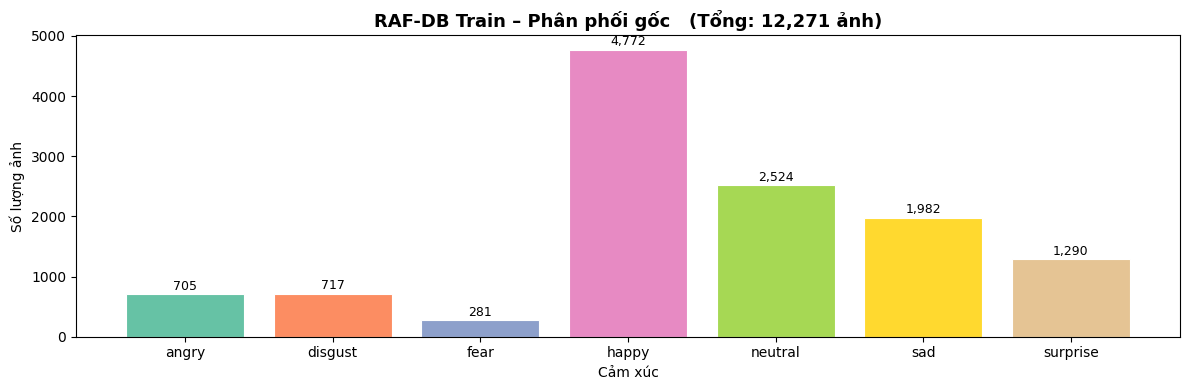


Nhãn              Số ảnh   Tỉ lệ
--------------------------------------------------
  angry              705   ███
  disgust            717   ███
  fear               281   █
  happy            4,772   █████████████████████████
  neutral          2,524   █████████████
  sad              1,982   ██████████
  surprise         1,290   ██████

✅ Số nhãn  : 7
   Tên nhãn : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

💡 Phân phối lệch:
   fear         : 281
   angry        : 705
   disgust      : 717
   surprise     : 1,290
   sad          : 1,982
   neutral      : 2,524
   happy        : 4,772

   → Sẽ cân bằng về 1,500 ảnh/nhãn


In [10]:
# =====================================================================
# CELL 6: VISUALIZE PHÂN PHỐI GỐC
# =====================================================================
print("="*55)
print("📊 PHÂN PHỐI RAF-DB TRAIN (7 nhãn, gốc)")
print("="*55)

train_info  = load_dataset_info(os.path.join(ORGANIZED_DIR, "train"))
visualize_distribution(train_info, "RAF-DB Train – Phân phối gốc")

CLASS_NAMES = sorted(train_info.keys())
NUM_CLASSES  = len(CLASS_NAMES)
counts       = {l: len(v) for l, v in train_info.items()}

print(f"\n✅ Số nhãn  : {NUM_CLASSES}")
print(f"   Tên nhãn : {CLASS_NAMES}")
print(f"\n💡 Phân phối lệch:")
for l in sorted(counts, key=counts.get):
    print(f"   {l:<13}: {counts[l]:,}")
print(f"\n   → Sẽ cân bằng về {TARGET_PER_CLASS:,} ảnh/nhãn")


🔄 CÂN BẰNG DATASET
   Mục tiêu : 1,500 ảnh/nhãn
   Số nhãn  : 7

  [angry       ]  📋 Giữ nguyên : 705
               ➕ Oversample : +795 ảnh (2.1× aug ratio)
               ✅ 1,500 ảnh

  [disgust     ]  📋 Giữ nguyên : 717
               ➕ Oversample : +783 ảnh (2.1× aug ratio)
               ✅ 1,500 ảnh

  [fear        ]  📋 Giữ nguyên : 281
               ➕ Oversample : +1,219 ảnh (5.3× aug ratio)
               ✅ 1,500 ảnh

  [happy       ]  ✂️  Undersample: 4,772 → 1,500
               ✅ 1,500 ảnh

  [neutral     ]  ✂️  Undersample: 2,524 → 1,500
               ✅ 1,500 ảnh

  [sad         ]  ✂️  Undersample: 1,982 → 1,500
               ✅ 1,500 ảnh

  [surprise    ]  📋 Giữ nguyên : 1,290
               ➕ Oversample : +210 ảnh (1.2× aug ratio)
               ✅ 1,500 ảnh

🎉 Cân bằng hoàn tất!  Tổng: 10,500 ảnh



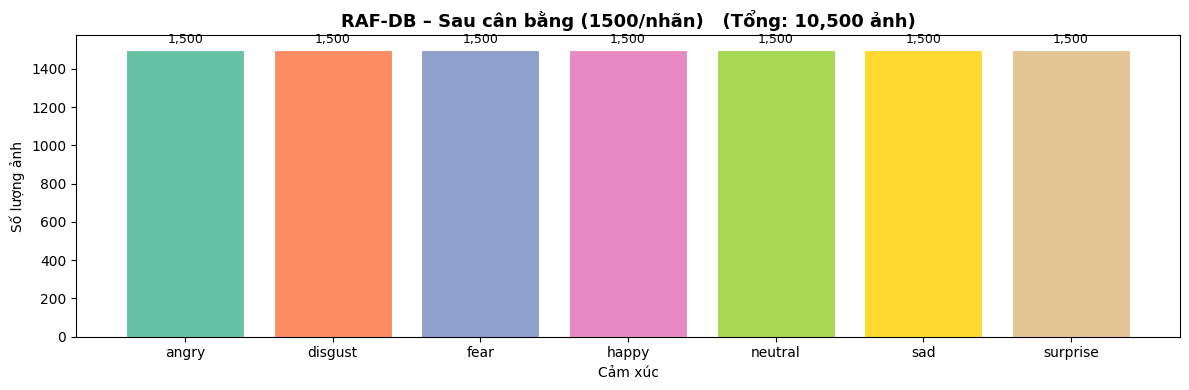


Nhãn              Số ảnh   Tỉ lệ
--------------------------------------------------
  angry            1,500   █████████████████████████
  disgust          1,500   █████████████████████████
  fear             1,500   █████████████████████████
  happy            1,500   █████████████████████████
  neutral          1,500   █████████████████████████
  sad              1,500   █████████████████████████
  surprise         1,500   █████████████████████████


In [7]:
# =====================================================================
# CELL 7: CÂN BẰNG DATASET VỀ 1500 ẢNH/NHÃN
# =====================================================================
def augment_image(img):
    """Augment ngẫu nhiên 1 ảnh numpy uint8."""
    if np.random.rand() > 0.5:
        img = cv2.flip(img, 1) #lat ngang
    angle = np.random.uniform(-15, 15)
    M = cv2.getRotationMatrix2D( 
        (img.shape[1]//2, img.shape[0]//2), angle, 1.0)
    img = cv2.warpAffine(img, M, (img.shape[1], img.shape[0]),
                         borderMode=cv2.BORDER_REFLECT)
    alpha = np.random.uniform(0.80, 1.20)
    beta  = np.random.randint(-20, 20)
    img   = np.clip(alpha*img.astype(np.float32)+beta,
                    0, 255).astype(np.uint8)
    tx = np.random.randint(-5, 5)
    ty = np.random.randint(-5, 5)
    M2 = np.float32([[1, 0, tx], [0, 1, ty]])
    img = cv2.warpAffine(img, M2, (img.shape[1], img.shape[0]),
                         borderMode=cv2.BORDER_REFLECT)
    # Thêm Gaussian noise nhẹ
    if np.random.rand() > 0.5:
        noise = np.random.normal(0, 3, img.shape).astype(np.int16)
        img   = np.clip(img.astype(np.int16) + noise,
                        0, 255).astype(np.uint8)
    return img


def balance_dataset(source_dir, output_dir,
                    target_per_class=1500, img_size=100):
    if os.path.exists(output_dir) and os.listdir(output_dir):
        counts = {
            l: len(os.listdir(os.path.join(output_dir, l)))
            for l in os.listdir(output_dir)
            if os.path.isdir(os.path.join(output_dir, l))
        }
        print("⚠️  Balanced dataset đã tồn tại:")
        for l, c in counts.items():
            print(f"     {l:<13}: {c:,} ảnh")
        return

    dataset = load_dataset_info(source_dir)
    print(f"\n{'='*55}")
    print(f"🔄 CÂN BẰNG DATASET")
    print(f"   Mục tiêu : {target_per_class:,} ảnh/nhãn")
    print(f"   Số nhãn  : {len(dataset)}")
    print(f"{'='*55}\n")

    for label, paths in sorted(dataset.items()):
        out_dir = os.path.join(output_dir, label)
        os.makedirs(out_dir, exist_ok=True)
        n_orig  = len(paths)

        images = []
        for p in paths:
            img = cv2.imread(p)
            if img is None: continue
            img = cv2.resize(img, (img_size, img_size),
                             interpolation=cv2.INTER_CUBIC)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            images.append(img)
        if not images: continue
        images = np.array(images)

        if len(images) > target_per_class:
            idx    = np.random.choice(len(images),
                                      target_per_class, replace=False)
            images = images[idx]
            action = f"✂️  Undersample: {n_orig:,} → {target_per_class:,}"
        else:
            action = f"📋 Giữ nguyên : {n_orig:,}"

        for i, img in enumerate(images):
            cv2.imwrite(
                os.path.join(out_dir, f"orig_{i:05d}.png"),
                cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
            )

        needed  = target_per_class - len(images)
        aug_txt = ""
        if needed > 0:
            ratio   = target_per_class / max(n_orig, 1)
            aug_txt = (f"➕ Oversample : +{needed:,} ảnh "
                       f"({ratio:.1f}× aug ratio)")
            for k in range(needed):
                src = images[np.random.randint(len(images))].copy()
                cv2.imwrite(
                    os.path.join(out_dir, f"aug_{k:05d}.png"),
                    cv2.cvtColor(augment_image(src), cv2.COLOR_RGB2BGR)
                )

        final = len(os.listdir(out_dir))
        print(f"  [{label:<12}]  {action}")
        if aug_txt:
            print(f"               {aug_txt}")
        print(f"               ✅ {final:,} ảnh\n")

    total = sum(
        len(os.listdir(os.path.join(output_dir, l)))
        for l in os.listdir(output_dir)
        if os.path.isdir(os.path.join(output_dir, l))
    )
    print(f"🎉 Cân bằng hoàn tất!  Tổng: {total:,} ảnh")


balance_dataset(
    source_dir       = os.path.join(ORGANIZED_DIR, "train"),
    output_dir       = BALANCED_DIR,
    target_per_class = TARGET_PER_CLASS,
    img_size         = IMG_SIZE
)

print("\n"+"="*55)
balanced_info = load_dataset_info(BALANCED_DIR)
visualize_distribution(balanced_info,
                       f"RAF-DB – Sau cân bằng ({TARGET_PER_CLASS}/nhãn)")

In [8]:
# =====================================================================
# CELL 8: CHIA TRAIN / VAL = 80 / 20
# =====================================================================
def split_train_val(source_dir, output_dir, val_ratio=0.2, seed=42):
    train_out = os.path.join(output_dir, "train")
    val_out   = os.path.join(output_dir, "val")

    if os.path.exists(train_out) and os.path.exists(val_out):
        n_t = sum(
            len(os.listdir(os.path.join(train_out, l)))
            for l in os.listdir(train_out)
            if os.path.isdir(os.path.join(train_out, l))
        )
        n_v = sum(
            len(os.listdir(os.path.join(val_out, l)))
            for l in os.listdir(val_out)
            if os.path.isdir(os.path.join(val_out, l))
        )
        print(f"⚠️  Split đã tồn tại → "
              f"Train: {n_t:,}  |  Val: {n_v:,}")
        return train_out, val_out

    random.seed(seed)
    dataset = load_dataset_info(source_dir)
    print(f"\n{'='*55}")
    print(f"✂️  CHIA TRAIN / VAL  (80% / 20%)")
    print(f"{'='*55}\n")

    total_t = total_v = 0
    for label, paths in sorted(dataset.items()):
        random.shuffle(paths)
        n_v     = int(len(paths) * val_ratio)
        val_p   = paths[:n_v]
        train_p = paths[n_v:]
        for sname, sp in [("train", train_p), ("val", val_p)]:
            dest = os.path.join(output_dir, sname, label)
            os.makedirs(dest, exist_ok=True)
            for src in sp:
                shutil.copy2(src, os.path.join(dest,
                                               os.path.basename(src)))
        total_t += len(train_p)
        total_v += len(val_p)
        print(f"  [{label:<12}]  "
              f"train: {len(train_p):4,}  |  val: {len(val_p):4,}")

    pct_t = total_t / (total_t + total_v) * 100
    pct_v = total_v / (total_t + total_v) * 100
    print(f"\n✅ Tổng → Train: {total_t:,}  |  Val: {total_v:,}  "
          f"({pct_t:.1f}% / {pct_v:.1f}%)")
    return train_out, val_out


TRAIN_SPLIT, VAL_SPLIT = split_train_val(
    BALANCED_DIR, SPLIT_DIR, VAL_RATIO
)


✂️  CHIA TRAIN / VAL  (80% / 20%)

  [angry       ]  train: 1,200  |  val:  300
  [disgust     ]  train: 1,200  |  val:  300
  [fear        ]  train: 1,200  |  val:  300
  [happy       ]  train: 1,200  |  val:  300
  [neutral     ]  train: 1,200  |  val:  300
  [sad         ]  train: 1,200  |  val:  300
  [surprise    ]  train: 1,200  |  val:  300

✅ Tổng → Train: 8,400  |  Val: 2,100  (80.0% / 20.0%)


In [9]:
# =====================================================================
# CELL 9: DATA GENERATORS
# =====================================================================
train_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input,  # chuẩn EfficientNet
    horizontal_flip        = True,
    rotation_range         = 15,
    width_shift_range      = 0.12,
    height_shift_range     = 0.12,
    zoom_range             = 0.12,
    shear_range            = 0.1,
    brightness_range       = [0.8, 1.2],
    fill_mode              = 'reflect'
)
val_test_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_SPLIT,
    target_size = (UPSAMPLE_SIZE, UPSAMPLE_SIZE),
    color_mode  = 'rgb',
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = True,
    seed        = 42
)
val_gen = val_test_datagen.flow_from_directory(
    VAL_SPLIT,
    target_size = (UPSAMPLE_SIZE, UPSAMPLE_SIZE),
    color_mode  = 'rgb',
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = False
)

CLASS_NAMES = sorted(load_dataset_info(BALANCED_DIR).keys())
NUM_CLASSES  = len(CLASS_NAMES)

test_gen = val_test_datagen.flow_from_directory(
    os.path.join(ORGANIZED_DIR, "test"),
    target_size = (UPSAMPLE_SIZE, UPSAMPLE_SIZE),
    color_mode  = 'rgb',
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = False,
    classes     = CLASS_NAMES
)

steps = train_gen.samples // BATCH_SIZE
est   = steps * 1.2 * (EPOCHS_PHASE1 + EPOCHS_PHASE2) / 3600

print(f"✅ Nhãn ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"   Train : {train_gen.samples:,}  → {steps} bước/epoch")
print(f"   Val   : {val_gen.samples:,}")
print(f"   Test  : {test_gen.samples:,}")
print(f"\n⏱️  Ước tính: ~{est:.1f} giờ (CPU)")
print(f"   (EfficientNetB3 nặng hơn MobileNetV2 ~40%)")

Found 8400 images belonging to 7 classes.
Found 2100 images belonging to 7 classes.
Found 3068 images belonging to 7 classes.
✅ Nhãn (7): ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
   Train : 8,400  → 525 bước/epoch
   Val   : 2,100
   Test  : 3,068

⏱️  Ước tính: ~14.9 giờ (CPU)
   (EfficientNetB3 nặng hơn MobileNetV2 ~40%)


In [10]:
# =====================================================================
# CELL 10: MIXUP GENERATOR
# =====================================================================
def mixup_generator(generator, alpha=0.2):
    """Mixup: trộn 2 ảnh + nhãn → model generalize tốt hơn."""
    while True:
        x1, y1 = next(generator)
        x2, y2 = next(generator)
        lam    = np.random.beta(alpha, alpha)
        yield lam*x1 + (1-lam)*x2, lam*y1 + (1-lam)*y2

print("✅ Mixup generator sẵn sàng  (alpha=0.2)")

✅ Mixup generator sẵn sàng  (alpha=0.2)


In [11]:
# =====================================================================
# CELL 11: XÂY DỰNG MODEL EfficientNetB3
# =====================================================================
def build_model(num_classes, img_size=128, lr=3e-4):
    inputs   = layers.Input(shape=(img_size, img_size, 3))
    backbone = EfficientNetB3(
        include_top  = False,
        weights      = 'imagenet',
        input_tensor = inputs,
        pooling      = None
    )
    backbone.trainable = False
    x   = backbone.output
    gap = layers.GlobalAveragePooling2D()(x)
    gmp = layers.GlobalMaxPooling2D()(x)`
    x   = layers.Concatenate()([gap, gmp])
    x   = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs,
                         name="EfficientNetB3_RAFDB")
    model.compile(
        optimizer = Adam(lr),
        loss      = tf.keras.losses.CategoricalCrossentropy(
                        label_smoothing=0.1),
        metrics   = ['accuracy']
    )
    return model, backbone


model, backbone = build_model(NUM_CLASSES, UPSAMPLE_SIZE, LR)

total_params     = model.count_params()
trainable_params = sum(tf.size(v).numpy()
                       for v in model.trainable_variables)
frozen_params    = total_params - trainable_params

print("="*65)
print(f"✅ Model            : {model.name}")
print(f"   Số nhãn          : {NUM_CLASSES}  →  {CLASS_NAMES}")
print(f"   Input size       : {UPSAMPLE_SIZE}×{UPSAMPLE_SIZE}×3")
print(f"   Tổng tham số     : {total_params:,}")
print(f"   Trainable params : {trainable_params:,}")
print(f"   Frozen params    : {frozen_params:,}")
print(f"   GAP + GMP concat : ✅")
print(f"   Label smoothing  : 0.1")
print(f"   Dropout          : 0.5 / 0.4 / 0.3")
print(f"   L2 regularizer   : 1e-4")
print("="*65)

# ── Summary đầy đủ ───────────────────────────────────────────────────
print("\n📄 MODEL SUMMARY:\n")
model.summary(line_length=90)

✅ Model            : EfficientNetB3_RAFDB
   Số nhãn          : 7  →  ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
   Input size       : 128×128×3
   Tổng tham số     : 12,534,326
   Trainable params : 1,744,647
   Frozen params    : 10,789,679
   GAP + GMP concat : ✅
   Label smoothing  : 0.1
   Dropout          : 0.5 / 0.4 / 0.3
   L2 regularizer   : 1e-4

📄 MODEL SUMMARY:



Model: "EfficientNetB3_RAFDB"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)             ┃ Output Shape         ┃      Param # ┃ Connected to          ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer) │ (None, 128, 128, 3)  │            0 │ -                     │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ rescaling (Rescaling)    │ (None, 128, 128, 3)  │            0 │ input_layer[0][0]     │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ normalization            │ (None, 128, 128, 3)  │            7 │ rescaling[0][0]       │
│ (Normalization)          │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ rescaling_1 (Rescaling)  │ (None, 128, 128, 3)  │            0 │ normalization[0][0]   │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ stem_conv_pad            │ (None, 129, 129, 3)  │            0 │ rescaling_1[0][0]     │
│ (ZeroPadding2D)          │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ stem_conv (Conv2D)       │ (None, 64, 64, 40)   │        1,080 │ stem_conv_pad[0][0]   │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ stem_bn                  │ (None, 64, 64, 40)   │          160 │ stem_conv[0][0]       │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ stem_activation          │ (None, 64, 64, 40)   │            0 │ stem_bn[0][0]         │
│ (Activation)             │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ block1a_dwconv           │ (None, 64, 64, 40)   │          360 │ stem_activation[0][0] │
│ (DepthwiseConv2D)        │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ block1a_bn               │ (None, 64, 64, 40)   │          160 │ block1a_dwconv[0][0]  │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ block1a_activation       │ (None, 64, 64, 40)   │            0 │ block1a_bn[0][0]      │
│ (Activation)             │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ block1a_se_squeeze       │ (None, 40)           │            0 │ block1a_activation[0… │
│ (GlobalAveragePooling2D) │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ block1a_se_reshape       │ (None, 1, 1, 40)     │            0 │ block1a_se_squeeze[0… │
│ (Reshape)                │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ block1a_se_reduce        │ (None, 1, 1, 10)     │          410 │ block1a_se_reshape[0… │
│ (Conv2D)                 │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ block1a_se_expand        │ (None, 1, 1, 40)     │          440 │ block1a_se_reduce[0]… │
│ (Conv2D)                 │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼─────────────────────

 Total params: 12,534,326 (47.81 MB)

 Trainable params: 1,744,647 (6.66 MB)

 Non-trainable params: 10,789,679 (41.16 MB)

In [12]:
# =====================================================================
# CELL 12: CALLBACKS
# =====================================================================
class WarmUpCosineDecay(tf.keras.callbacks.Callback):
    def __init__(self, lr_start, lr_max, warmup_epochs, total_epochs):
        super().__init__()
        self.lr_start      = lr_start
        self.lr_max        = lr_max
        self.warmup_epochs = warmup_epochs
        self.total_epochs  = total_epochs

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            lr = self.lr_start + (self.lr_max - self.lr_start) * \
                 (epoch / self.warmup_epochs)
        else:
            progress = ((epoch - self.warmup_epochs) /
                        max(1, self.total_epochs - self.warmup_epochs))
            lr = self.lr_max * 0.5 * \
                 (1 + math.cos(math.pi * progress))
        self.model.optimizer.learning_rate.assign(lr)
        if epoch % 5 == 0:
            print(f"\n   LR epoch {epoch+1}: {lr:.2e}")


BEST_MODEL_PATH  = os.path.join(MODEL_DIR, "best_emotion.keras")
FINAL_MODEL_PATH = os.path.join(MODEL_DIR, "final_emotion.keras")

callbacks_phase1 = [
    ModelCheckpoint(
        BEST_MODEL_PATH,
        monitor        = 'val_accuracy',
        save_best_only = True,
        verbose        = 1
    ),
    EarlyStopping(
        monitor              = 'val_accuracy',
        patience             = 12,
        restore_best_weights = True,
        verbose              = 1
    ),
    WarmUpCosineDecay(
        lr_start      = 1e-6,
        lr_max        = LR,
        warmup_epochs = 3,
        total_epochs  = EPOCHS_PHASE1
    )
]

callbacks_phase2 = [
    ModelCheckpoint(
        BEST_MODEL_PATH,
        monitor        = 'val_accuracy',
        save_best_only = True,
        verbose        = 1
    ),
    EarlyStopping(
        monitor              = 'val_accuracy',
        patience             = 12,
        restore_best_weights = True,
        verbose              = 1
    ),
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.3,
        patience = 4,
        min_lr   = 1e-7,
        verbose  = 1
    )
]

print("✅ Callbacks Phase 1: WarmUp Cosine Decay")
print("✅ Callbacks Phase 2: ReduceLROnPlateau")
print(f"   EarlyStopping patience : 12")

✅ Callbacks Phase 1: WarmUp Cosine Decay
✅ Callbacks Phase 2: ReduceLROnPlateau
   EarlyStopping patience : 12


In [13]:
# =====================================================================
# CELL 13: PHASE 1 – TRAIN HEAD (BACKBONE FROZEN)
# =====================================================================
print("="*55)
print("🚀 PHASE 1 – Train Head  |  Backbone FROZEN")
print(f"   Backbone : EfficientNetB3")
print(f"   Dataset  : RAF-DB  ({NUM_CLASSES} nhãn, "
      f"{TARGET_PER_CLASS}/nhãn)")
print(f"   Epochs   : {EPOCHS_PHASE1}  |  LR max: {LR}")
print(f"   Mixup    : alpha=0.2  |  WarmUp: 3 epochs")
print("="*55)

history1 = model.fit(
    mixup_generator(train_gen, alpha=0.2),
    steps_per_epoch = train_gen.samples // BATCH_SIZE,
    epochs          = EPOCHS_PHASE1,
    validation_data = val_gen,
    callbacks       = callbacks_phase1,
    verbose         = 1
)

best1 = max(history1.history['val_accuracy'])
print(f"\n✅ Phase 1 xong  |  Best val_acc: {best1*100:.2f}%")

🚀 PHASE 1 – Train Head  |  Backbone FROZEN
   Backbone : EfficientNetB3
   Dataset  : RAF-DB  (7 nhãn, 1500/nhãn)
   Epochs   : 25  |  LR max: 0.0003
   Mixup    : alpha=0.2  |  WarmUp: 3 epochs

   LR epoch 1: 1.00e-06
Epoch 1/25
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 629ms/step - accuracy: 0.1564 - loss: 3.1120
Epoch 1: val_accuracy improved from None to 0.15000, saving model to D:\XuLyAnh\workspace_efficientb3\models\best_emotion.keras
525/525 ━━━━━━━━━━━━━━━━━━━━ 409s 736ms/step - accuracy: 0.1493 - loss: 3.1099 - val_accuracy: 0.1500 - val_loss: 2.2320
Epoch 2/25
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.1669 - loss: 2.5601
Epoch 2: val_accuracy improved from 0.15000 to 0.30952, saving model to D:\XuLyAnh\workspace_efficientb3\models\best_emotion.keras
525/525 ━━━━━━━━━━━━━━━━━━━━ 267s 510ms/step - accuracy: 0.1902 - loss: 2.3768 - val_accuracy: 0.3095 - val_loss: 1.9525
Epoch 3/25
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.2242 - loss: 2.1436
Epoch 3: val_ac

In [14]:
# =====================================================================
# CELL 14: PHASE 2 – FINE-TUNE 30 LAYER CUỐI
# EfficientNetB3 sâu hơn MobileNetV2 nên fine-tune ít layer hơn
# =====================================================================
print("="*55)
print("🔧 PHASE 2 – Fine-tune 30 layer cuối backbone")
print(f"   Epochs : {EPOCHS_PHASE2}  |  LR: {LR/10:.1e}")
print("="*55)

backbone.trainable = True
for layer in backbone.layers[:-30]:
    layer.trainable = False

# Giữ BatchNorm frozen tránh distribution shift
for layer in backbone.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

n_open = sum(1 for l in backbone.layers if l.trainable)
print(f"   Layer mở   : {n_open} / {len(backbone.layers)}")
print(f"   BatchNorm  : frozen")

model.compile(
    optimizer = Adam(LR / 10),
    loss      = tf.keras.losses.CategoricalCrossentropy(
                    label_smoothing=0.1),
    metrics   = ['accuracy']
)

history2 = model.fit(
    mixup_generator(train_gen, alpha=0.2),
    steps_per_epoch = train_gen.samples // BATCH_SIZE,
    epochs          = EPOCHS_PHASE2,
    validation_data = val_gen,
    callbacks       = callbacks_phase2,
    verbose         = 1
)

best2 = max(history2.history['val_accuracy'])
print(f"\n✅ Phase 2 xong  |  Best val_acc: {best2*100:.2f}%")

🔧 PHASE 2 – Fine-tune 30 layer cuối backbone
   Epochs : 60  |  LR: 3.0e-05
   Layer mở   : 23 / 385
   BatchNorm  : frozen
Epoch 1/60
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.4498 - loss: 1.7618
Epoch 1: val_accuracy improved from None to 0.56381, saving model to D:\XuLyAnh\workspace_efficientb3\models\best_emotion.keras
525/525 ━━━━━━━━━━━━━━━━━━━━ 133s 236ms/step - accuracy: 0.4605 - loss: 1.7441 - val_accuracy: 0.5638 - val_loss: 1.5704 - learning_rate: 3.0000e-05
Epoch 2/60
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.4754 - loss: 1.7202
Epoch 2: val_accuracy improved from 0.56381 to 0.57571, saving model to D:\XuLyAnh\workspace_efficientb3\models\best_emotion.keras
525/525 ━━━━━━━━━━━━━━━━━━━━ 121s 231ms/step - accuracy: 0.4863 - loss: 1.7169 - val_accuracy: 0.5757 - val_loss: 1.5379 - learning_rate: 3.0000e-05
Epoch 3/60
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.4925 - loss: 1.7107
Epoch 3: val_accuracy improved from 0.57571 to 0.58286,

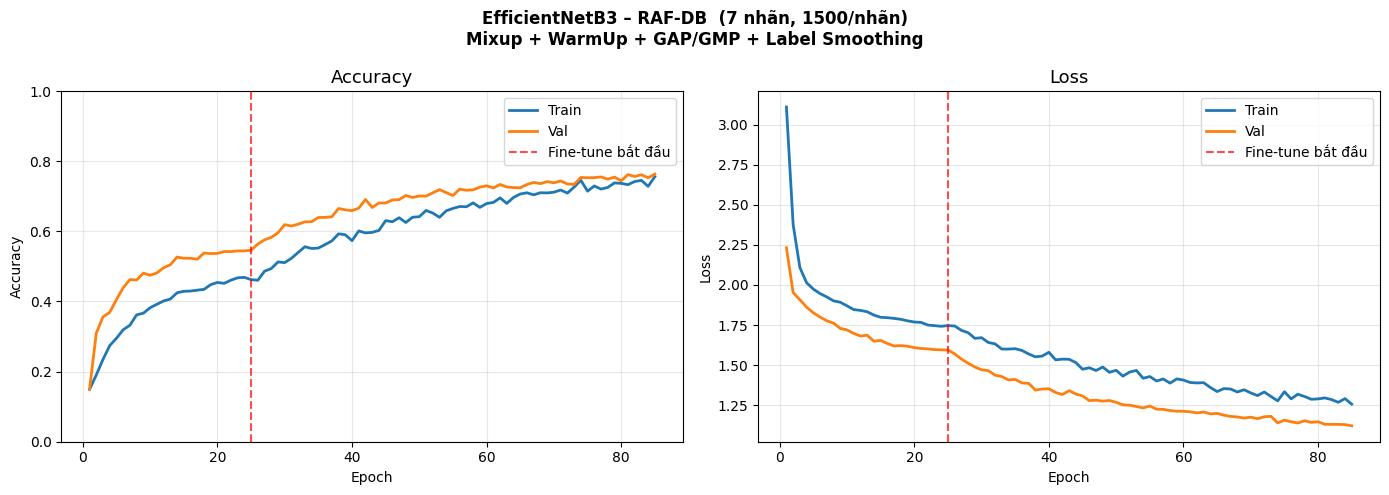

✅ Lưu → D:\XuLyAnh\workspace_efficientb3\models\training_history.png


In [15]:
# =====================================================================
# CELL 15: BIỂU ĐỒ TRAINING
# =====================================================================
def plot_history(h1, h2):
    acc   = h1.history['accuracy']     + h2.history['accuracy']
    val   = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss  = h1.history['loss']         + h2.history['loss']
    vloss = h1.history['val_loss']     + h2.history['val_loss']
    p1    = len(h1.history['accuracy'])
    ep    = range(1, len(acc)+1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(ep, acc, label='Train', linewidth=2)
    ax1.plot(ep, val, label='Val',   linewidth=2)
    ax1.axvline(p1, color='red', ls='--', alpha=0.7,
                label='Fine-tune bắt đầu')
    ax1.set_title('Accuracy', fontsize=13)
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.set_ylim(0, 1); ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(ep, loss,  label='Train', linewidth=2)
    ax2.plot(ep, vloss, label='Val',   linewidth=2)
    ax2.axvline(p1, color='red', ls='--', alpha=0.7,
                label='Fine-tune bắt đầu')
    ax2.set_title('Loss', fontsize=13)
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.suptitle(
        f"EfficientNetB3 – RAF-DB  ({NUM_CLASSES} nhãn, "
        f"{TARGET_PER_CLASS}/nhãn)\n"
        "Mixup + WarmUp + GAP/GMP + Label Smoothing",
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    save_p = os.path.join(MODEL_DIR, "training_history.png")
    plt.savefig(save_p, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Lưu → {save_p}")

plot_history(history1, history2)

📊 ĐÁNH GIÁ TRÊN RAF-DB TEST SET
192/192 ━━━━━━━━━━━━━━━━━━━━ 44s 214ms/step - accuracy: 0.6845 - loss: 1.2945

🎯 Test Loss    : 1.2945
🎯 Test Accuracy: 68.45%
192/192 ━━━━━━━━━━━━━━━━━━━━ 29s 142ms/step

📋 Classification Report:
              precision    recall  f1-score   support

       angry     0.5882    0.6790    0.6304       162
     disgust     0.3119    0.2125    0.2528       160
        fear     0.6066    0.5000    0.5481        74
       happy     0.9077    0.7224    0.8045      1185
     neutral     0.5867    0.7118    0.6432       680
         sad     0.6152    0.7092    0.6589       478
    surprise     0.6122    0.7295    0.6657       329

    accuracy                         0.6845      3068
   macro avg     0.6041    0.6092    0.6005      3068
weighted avg     0.7041    0.6845    0.6870      3068



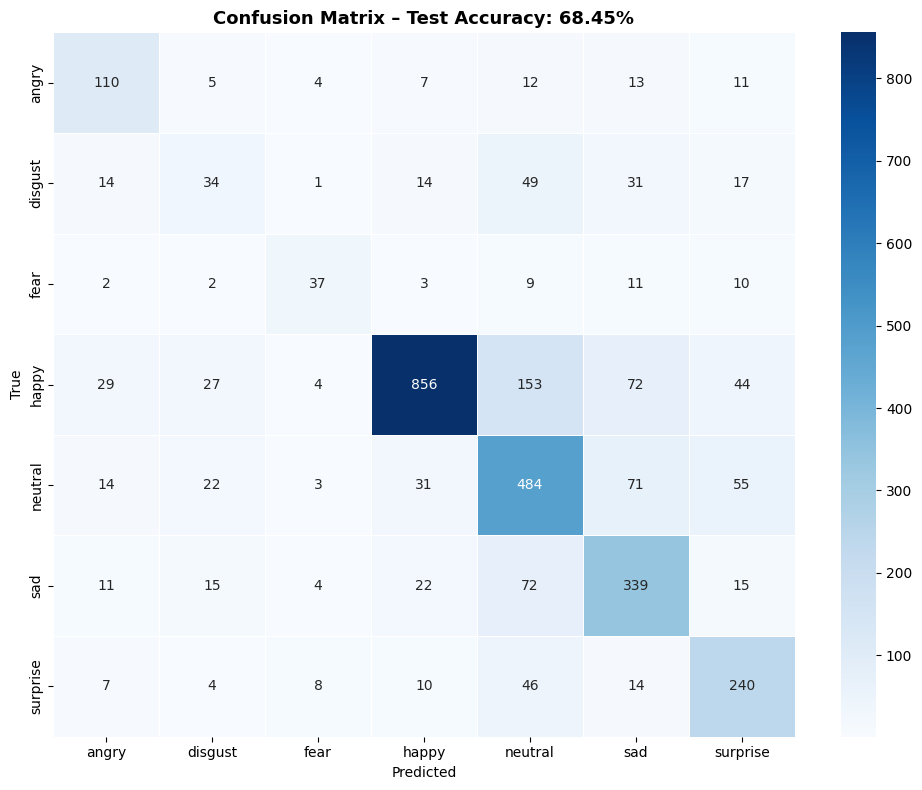

✅ Lưu → D:\XuLyAnh\workspace_efficientb3\models\confusion_matrix.png


In [16]:
# =====================================================================
# CELL 16: ĐÁNH GIÁ TEST SET + CONFUSION MATRIX
# =====================================================================
print("="*55)
print("📊 ĐÁNH GIÁ TRÊN RAF-DB TEST SET")
print("="*55)

best_model = tf.keras.models.load_model(BEST_MODEL_PATH)
test_loss, test_acc = best_model.evaluate(test_gen, verbose=1)

print(f"\n🎯 Test Loss    : {test_loss:.4f}")
print(f"🎯 Test Accuracy: {test_acc*100:.2f}%")

test_gen.reset()
y_pred = np.argmax(best_model.predict(test_gen, verbose=1), axis=1)
y_true = test_gen.classes

print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred,
                             target_names=CLASS_NAMES, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            linewidths=0.5)
plt.title(f"Confusion Matrix – Test Accuracy: {test_acc*100:.2f}%",
          fontsize=13, fontweight='bold')
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout()
save_p = os.path.join(MODEL_DIR, "confusion_matrix.png")
plt.savefig(save_p, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Lưu → {save_p}")

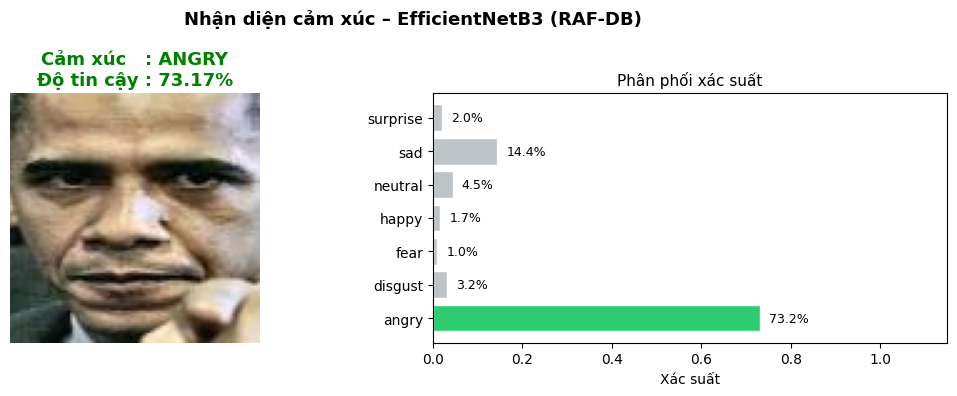

✅ ANGRY  |  73.17%


In [17]:
# =====================================================================
# CELL 17: DỰ ĐOÁN ẢNH ĐƠN LẺ
# =====================================================================
def predict_emotion(img_path, model, class_names, img_size=128):
    img = cv2.imread(img_path)
    if img is None:
        print(f"❌ Không đọc được: {img_path}"); return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    inp     = cv2.resize(img_rgb, (img_size, img_size),
                         interpolation=cv2.INTER_CUBIC)
    inp     = preprocess_input(inp.astype(np.float32))
    inp     = np.expand_dims(inp, axis=0)

    probs    = model.predict(inp, verbose=0)[0]
    pred_idx = np.argmax(probs)
    pred_lb  = class_names[pred_idx]
    conf     = probs[pred_idx]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
    ax1.imshow(img_rgb); ax1.axis('off')
    ax1.set_title(
        f"Cảm xúc   : {pred_lb.upper()}\n"
        f"Độ tin cậy : {conf:.2%}",
        fontsize=13, fontweight='bold',
        color='green' if conf > 0.6 else 'orange'
    )
    colors = ['#2ecc71' if i==pred_idx else '#bdc3c7'
              for i in range(len(class_names))]
    ax2.barh(class_names, probs, color=colors, edgecolor='white')
    ax2.set_xlim(0, 1.15); ax2.set_xlabel('Xác suất')
    ax2.set_title('Phân phối xác suất', fontsize=11)
    for i, v in enumerate(probs):
        ax2.text(v+0.02, i, f"{v:.1%}", va='center', fontsize=9)
    plt.suptitle("Nhận diện cảm xúc – EfficientNetB3 (RAF-DB)",
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()
    print(f"✅ {pred_lb.upper()}  |  {conf:.2%}")


first_label = CLASS_NAMES[0]
test_label_dir = os.path.join(ORGANIZED_DIR, "test", first_label)
sample = os.path.join(test_label_dir,
                      os.listdir(test_label_dir)[0])
predict_emotion(sample, best_model, CLASS_NAMES, UPSAMPLE_SIZE)

In [18]:
# =====================================================================
# CELL 18: LƯU MODEL & TÓM TẮT
# =====================================================================
best_model.save(FINAL_MODEL_PATH)

print("="*55)
print("💾 FILE ĐÃ LƯU:")
print(f"   {MODEL_DIR}")
print("="*55)
print(f"   best_emotion.keras      → model tốt nhất")
print(f"   final_emotion.keras     → model sau epoch cuối")
print(f"   training_history.png    → biểu đồ training")
print(f"   confusion_matrix.png    → confusion matrix")

print(f"\n{'='*55}")
print("📌 TÓM TẮT CẢI TIẾN SO VỚI LẦN TRƯỚC")
print("="*55)
print(f"  Backbone      : EfficientNetB3  ← đổi từ MobileNetV2")
print(f"  Dataset       : RAF-DB")
print(f"  Số nhãn       : {NUM_CLASSES}  →  {CLASS_NAMES}")
print(f"  Ảnh/nhãn     : {TARGET_PER_CLASS:,}  ← tăng từ 1000")
print(f"  UPSAMPLE_SIZE : {UPSAMPLE_SIZE}×{UPSAMPLE_SIZE}  ← tăng từ 112")
print(f"  BATCH_SIZE    : {BATCH_SIZE}  ← giảm từ 32")
print(f"  LR            : {LR}  ← giảm từ 5e-4")
print(f"  Fine-tune     : 30 layer  ← giảm từ 50 (B3 sâu hơn)")
print(f"  Train/Val     : 80% / 20%")
print(f"  Lần trước     : 66.33% (MobileNetV2)")
print(f"  Lần này       : {test_acc*100:.2f}%  (EfficientNetB3)")
print("="*55)

💾 FILE ĐÃ LƯU:
   D:\XuLyAnh\workspace_efficientb3\models
   best_emotion.keras      → model tốt nhất
   final_emotion.keras     → model sau epoch cuối
   training_history.png    → biểu đồ training
   confusion_matrix.png    → confusion matrix

📌 TÓM TẮT CẢI TIẾN SO VỚI LẦN TRƯỚC
  Backbone      : EfficientNetB3  ← đổi từ MobileNetV2
  Dataset       : RAF-DB
  Số nhãn       : 7  →  ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
  Ảnh/nhãn     : 1,500  ← tăng từ 1000
  UPSAMPLE_SIZE : 128×128  ← tăng từ 112
  BATCH_SIZE    : 16  ← giảm từ 32
  LR            : 0.0003  ← giảm từ 5e-4
  Fine-tune     : 30 layer  ← giảm từ 50 (B3 sâu hơn)
  Train/Val     : 80% / 20%
  Lần trước     : 66.33% (MobileNetV2)
  Lần này       : 68.45%  (EfficientNetB3)
